In [ ]:
###PRUEBA ANALISIS DEL DECAIMIENTO DEL MESON B

In [1]:
pip install uproot awkward awkward-pandas

Note: you may need to restart the kernel to use updated packages.


In [8]:
#importar datos

file_path = "opendata-project-1.1/Data/PhaseSpaceSimulation.root"

In [3]:
import numpy as np
import os
import uproot
import pandas
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

In [13]:
#Cargamos los datos
with uproot.open(f"{file_path}:PhaseSpaceTree") as data:
        sim_data = data.arrays(library="pd")

In [15]:
#Tabal de datos

sim_data.head()

,B_FlightDistance,B_VertexChi2,H1_PX,H1_PY,H1_PZ,H1_ProbK,H1_ProbPi,H1_Charge,H1_IPChi2,H1_isMuon,...,H2_IPChi2,H2_isMuon,H3_PX,H3_PY,H3_PZ,H3_ProbK,H3_ProbPi,H3_Charge,H3_IPChi2,H3_isMuon
0,0.0,1.0,3551.84,1636.96,23904.14,1.0,0.0,-1,1.0,0,...,1.0,0,36100.40,16546.83,295600.61,1.0,0.0,-1,1.0,0
1,0.0,1.0,-2525.98,-5284.05,35822.00,1.0,0.0,1,1.0,0,...,1.0,0,-8648.32,-16617.56,98535.13,1.0,0.0,-1,1.0,0
2,0.0,1.0,-700.67,1299.73,8127.76,1.0,0.0,-1,1.0,0,...,1.0,0,-13483.34,10860.77,79787.59,1.0,0.0,1,1.0,0
3,0.0,1.0,3364.63,1397.30,222815.29,1.0,0.0,1,1.0,0,...,1.0,0,1925.16,-551.12,40420.96,1.0,0.0,1,1.0,0
4,0.0,1.0,-581.66,-1305.24,22249.59,1.0,0.0,-1,1.0,0,...,1.0,0,-2820.04,-8305.43,250130.00,1.0,0.0,-1,1.0,0


In [ ]:
###VALORES TEORICOSS

/tmp/ipykernel_20716/622318744.py:4: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(sim_df['H1_PX'],500,[-9000,9000],color="green")   #distribución de la componente x del momento de un candidato a kaón


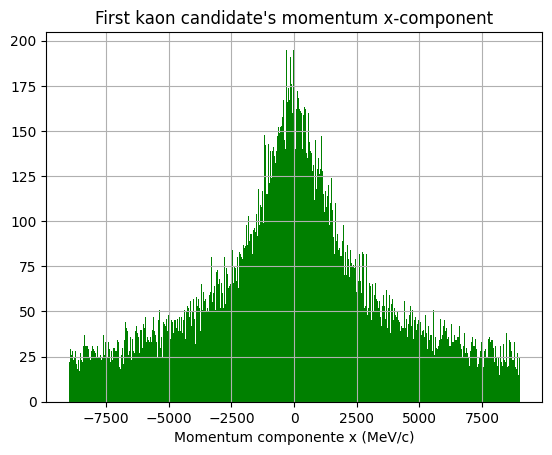

In [16]:
# Histograma de H1_PX variable 

sim_df = sim_data.copy()
plt.hist(sim_df['H1_PX'],500,[-9000,9000],color="green")   #distribución de la componente x del momento de un candidato a kaón
plt.xlabel("Momentum componente x (MeV/c)")
plt.title("First kaon candidate's momentum x-component")
plt.grid()
plt.show()

/tmp/ipykernel_20716/1103567771.py:6: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(sim_df['H1_P'],100,[0,700000],color="red")


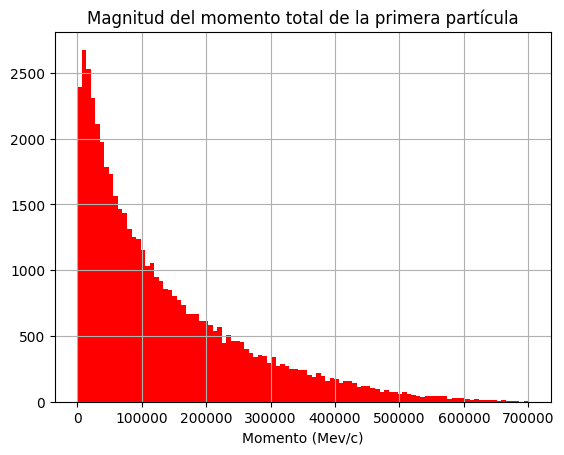

In [17]:
# calculate a variable for the magnitude of the momentum of the first kaon

sim_df['H1_P']=np.sqrt(sim_df['H1_PX']**2+sim_df['H1_PY']**2+sim_df['H1_PZ']**2)
# plot a histogram of this variable

plt.hist(sim_df['H1_P'],100,[0,700000],color="red")
plt.xlabel("Momento (Mev/c)")
plt.title("Magnitud del momento total de la primera partícula")
plt.grid()
plt.show()

In [18]:
# calculate the energy of the first kaon
sim_df['H1_E']=np.sqrt(sim_df['H1_P']**2+493.677**2)

/tmp/ipykernel_20716/3222606460.py:2: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(sim_df['H1_E'],100,[0,700000],color="green")


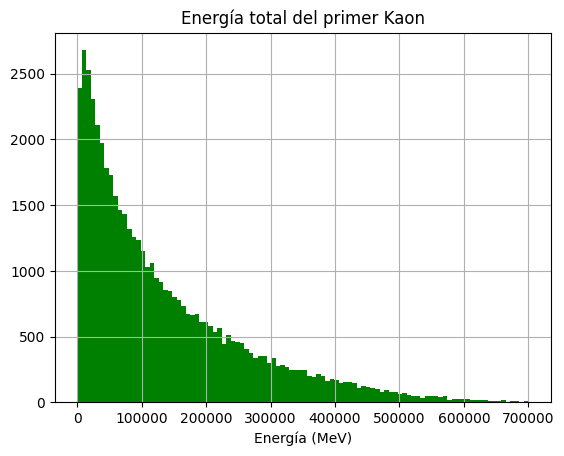

In [19]:
# plot a histogram of this variable
plt.hist(sim_df['H1_E'],100,[0,700000],color="green")
plt.xlabel("Energía (MeV)")
plt.title("Energía total del primer Kaon")
plt.grid()
plt.show()

In [21]:
# calculate variables for the energy of the other two kaons

sim_df['H2_P']=np.sqrt(sim_df['H2_PX']**2+sim_df['H2_PY']**2+sim_df['H2_PZ']**2)  #mismo proceso para los otros dos candidatos a kaones
sim_df['H3_P']=np.sqrt(sim_df['H3_PX']**2+sim_df['H3_PY']**2+sim_df['H3_PZ']**2)  #momentos

#Energia
sim_df['H2_E']=np.sqrt(sim_df['H2_P']**2+493.677**2)
sim_df['H3_E']=np.sqrt(sim_df['H3_P']**2+493.677**2)


In [22]:
# calculate the energy of the B meson
sim_df['B_E']=sim_df['H1_E']+sim_df['H2_E']+sim_df['H3_E']

In [23]:
# calculate the momentum components of the B meson
sim_df['B_PX']=sim_df['H1_PX']+sim_df['H2_PX']+sim_df['H3_PX']       #es necesario calcular cada componente
sim_df['B_PY']=sim_df['H1_PY']+sim_df['H2_PY']+sim_df['H3_PY']       #el momento es un vector
sim_df['B_PZ']=sim_df['H1_PZ']+sim_df['H2_PZ']+sim_df['H3_PZ']
# and the magnitude of the momentum of the B meson
sim_df['B_P']=np.sqrt(sim_df['B_PX']**2+sim_df['B_PY']**2+sim_df['B_PZ']**2)

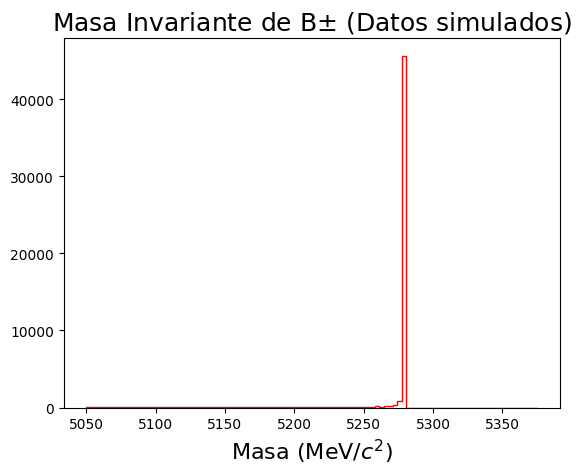

In [24]:
# calculate the B meson invariant mass
sim_df['B_M']=np.sqrt(sim_df['B_E']**2-sim_df['B_P']**2)
# plot the B meson invariant mass in a histogram

plt.hist(sim_df['B_M'], bins=100,range=(5050,5375), color = "red", histtype='step')
plt.xlabel(r"Masa (MeV/$c^2$)", fontsize = 16)
plt.title(r"Masa Invariante de B$\pm$ (Datos simulados)",fontsize=18)
plt.show()

In [ ]:
###REAL DATA

In [25]:
# Make your preselection here, this line applies no preselection

###PRESELECCION

preselection =("(H1_isMuon==0) & (H2_isMuon==0) & (H3_isMuon==0) & (H1_ProbK-1.5*H1_ProbPi>0) & (H2_ProbK-1.5*H2_ProbPi>0) & (H3_ProbK-1.5*H3_ProbPi>0)& "
    "(B_VertexChi2<10) & (H1_IPChi2>10) & (H2_IPChi2>10) & (H3_IPChi2>10) ")

In [29]:
#Calculamos la cantidad de eventos antes de aplicar la preselección

# Lee el archivo sin aplicar la preselección
with uproot.open("opendata-project-1.1/Data/B2HHH_MagnetUp.root:DecayTree") as data:
    before_real_data = data.arrays(data.keys(),library="pd")

with uproot.open("opendata-project-1.1/Data/B2HHH_MagnetDown.root:DecayTree") as data:
    before_real_data._append(data.arrays(data.keys(),library="pd"), ignore_index=True)

# Suma los eventos de ambos archivos
print("Número total de eventos antes de la preselección:", len(before_real_data))

Número total de eventos antes de la preselección: 3420295


In [31]:
with uproot.open("opendata-project-1.1/Data/B2HHH_MagnetUp.root:DecayTree") as data:
    real_data = data.arrays(data.keys(),preselection,library="pd")

with uproot.open("opendata-project-1.1/Data/B2HHH_MagnetDown.root:DecayTree") as data:
    real_data._append(data.arrays(data.keys(),preselection,library="pd"), ignore_index=True)

print("Número total de eventos después de la preselección:", len(real_data))

Número total de eventos después de la preselección: 12273


In [32]:
real_data.head()

,B_FlightDistance,B_VertexChi2,H1_PX,H1_PY,H1_PZ,H1_ProbK,H1_ProbPi,H1_Charge,H1_IPChi2,H1_isMuon,...,H2_IPChi2,H2_isMuon,H3_PX,H3_PY,H3_PZ,H3_ProbK,H3_ProbPi,H3_Charge,H3_IPChi2,H3_isMuon
325,10.428140,4.056947,-4168.055539,-704.953919,24548.766576,0.771199,0.051726,-1,1002.657075,0,...,714.174519,0,-8864.962492,-7428.640292,77446.175923,0.934580,0.128720,1,536.585115,0
495,5.796507,4.632833,1146.863275,62.865955,17993.678629,0.353851,0.104533,1,775.135404,0,...,253.494081,0,-2510.373706,-125.031711,22699.566908,0.958085,0.094597,-1,197.157935,0
517,14.308634,1.517676,4148.543227,1120.800651,32570.667856,0.942564,0.096867,1,1822.312429,0,...,2165.930625,0,3513.343363,803.938272,62451.266172,0.923655,0.130080,-1,1815.160743,0
539,33.591307,2.220242,1295.910334,-61.956920,35569.606902,0.932006,0.058690,-1,6672.092707,0,...,737.219732,0,-341.750434,3317.423370,24380.200353,0.968883,0.129317,1,23332.453390,0
1203,3.129789,5.072809,1421.948854,-666.134777,14676.910600,0.288271,0.045293,1,471.351129,0,...,45.250334,0,-2189.941266,950.500098,23930.313780,0.782511,0.069866,-1,505.737916,0


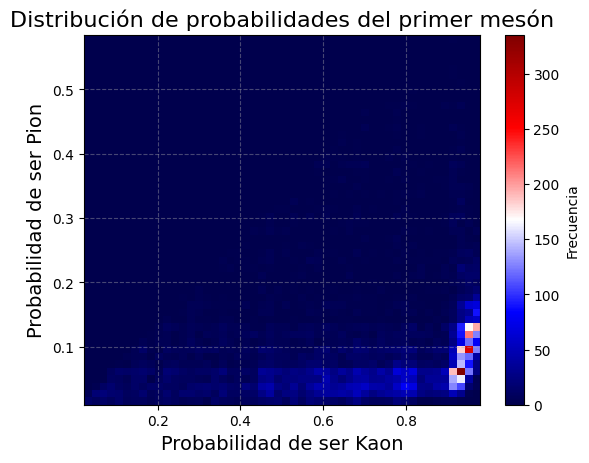

In [33]:
# plot the probability that a final state particle is a kaon and a pion in histogram 2D
plt.hist2d(real_data['H1_ProbK'], real_data['H1_ProbPi'], bins=50, cmap='seismic')
plt.colorbar(label='Frecuencia')

#Nombre de los ejes
plt.xlabel('Probabilidad de ser Kaon', fontsize=14)
plt.ylabel('Probabilidad de ser Pion', fontsize=14)
plt.title('Distribución de probabilidades del primer mesón', fontsize=16)

# Agregar una cuadrícula
plt.grid(True, linestyle='--', alpha=0.4)

# Mostrar el gráfico
plt.show()

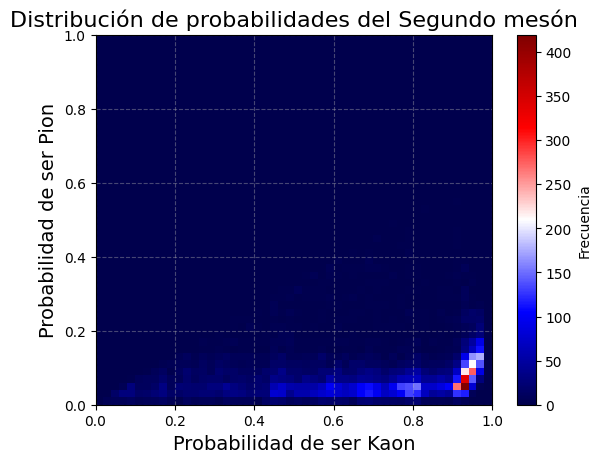

In [34]:
#plot the probability that a final state particle is a kaon and a pion in histogram 2D (SEGUNDO MESÓN)
plt.hist2d(real_data['H2_ProbK'], real_data['H2_ProbPi'], bins=50, range=[[0, 1], [0, 1]], cmap='seismic')
plt.colorbar(label='Frecuencia')

#Nombre de los ejes
plt.xlabel('Probabilidad de ser Kaon', fontsize=14)
plt.ylabel('Probabilidad de ser Pion', fontsize=14)
plt.title('Distribución de probabilidades del Segundo mesón', fontsize=16)

# Agregar una cuadrícula
plt.grid(True, linestyle='--', alpha=0.4)

# Mostrar el gráfico
plt.show()

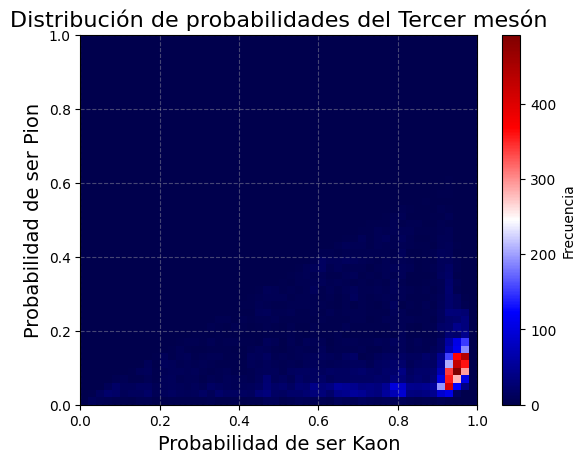

In [35]:
#plot the probability that a final state particle is a kaon and a pion in histogram 2D (TERCER MESÓN)
plt.hist2d(real_data['H3_ProbK'], real_data['H3_ProbPi'], bins=50, range=[[0, 1], [0, 1]], cmap='seismic')
plt.colorbar(label='Frecuencia')

#Nombre de los ejes
plt.xlabel('Probabilidad de ser Kaon', fontsize=14)
plt.ylabel('Probabilidad de ser Pion', fontsize=14)
plt.title('Distribución de probabilidades del Tercer mesón', fontsize=16)

# Agregar una cuadrícula
plt.grid(True, linestyle='--', alpha=0.4)

# Mostrar el gráfico
plt.show()


In [36]:
#Se define una función que calcule la energía, momentum total y masa invariante
def calcular_energia_momentum(df, px_col, py_col, pz_col, masa_particula, sufijo):
    # Calcular el momentum total
    df[f'{sufijo}_P'] = np.sqrt(df[px_col]**2 + df[py_col]**2 + df[pz_col]**2)

    # Calcular la energía total
    df[f'{sufijo}_E'] = np.sqrt(df[f'{sufijo}_P']**2 + masa_particula**2)

    # Calcular la masa invariante
    df[f'{sufijo}_M'] = np.sqrt(df[f'{sufijo}_E']**2 - df[f'{sufijo}_P']**2)

    return df

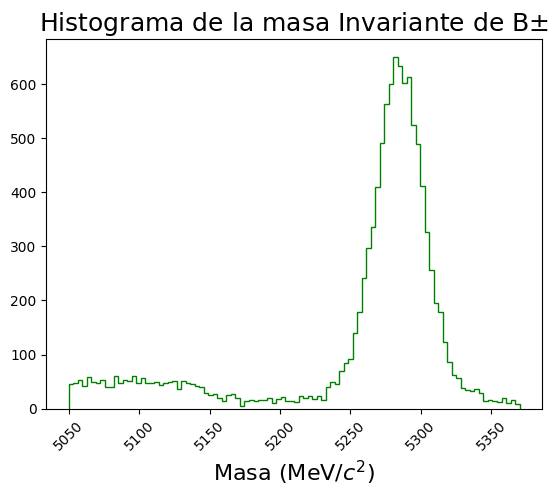

In [37]:
# draw a histogram for the B meson mass in the real data
real_df=real_data.copy()

#Calculo de la energía, momentum y masa invariante de las tres partículas
real_df = calcular_energia_momentum(real_df, 'H1_PX', 'H1_PY', 'H1_PZ', 493.677, 'H1')
real_df = calcular_energia_momentum(real_df, 'H2_PX', 'H2_PY', 'H2_PZ', 493.677, 'H2')
real_df = calcular_energia_momentum(real_df, 'H3_PX', 'H3_PY', 'H3_PZ', 493.677, 'H3')

#Energia y las tres componentes del momentum para B
real_df['B_E']=real_df['H1_E']+real_df['H2_E']+real_df['H3_E']
real_df['B_PX']=real_df['H1_PX']+real_df['H2_PX']+real_df['H3_PX']       #es necesario calcular cada componente
real_df['B_PY']=real_df['H1_PY']+real_df['H2_PY']+real_df['H3_PY']       #el momento es un vector
real_df['B_PZ']=real_df['H1_PZ']+real_df['H2_PZ']+real_df['H3_PZ']

#Calculo de la magnitud del momentum
real_df['B_P']=np.sqrt(real_df['B_PX']**2+real_df['B_PY']**2+real_df['B_PZ']**2)

#Calculo de la masa invariante de B
real_df['B_M']=np.sqrt(real_df['B_E']**2-real_df['B_P']**2)

# plot the B meson invariant mass in a histogram
plt.hist(real_df['B_M'],bins=100,range=(5050,5370),color ="green", histtype='step')
plt.xlabel(r"Masa (MeV/$c^2$)", fontsize = 16)
plt.title(r"Histograma de la masa Invariante de B$\pm$",fontsize=18)
# Modificar las marcas de graduación del eje x
plt.xticks(rotation=45)  # Ajusta el rango y la rotación
plt.show()


In [ ]:
##buscando diferencia materia antimateria

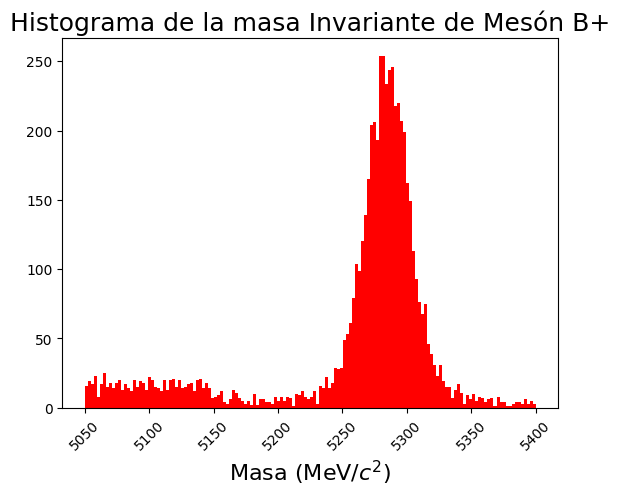

In [38]:
# make a variable for the charge of the B mesons
real_B=real_data[(real_data['H1_Charge'] + real_data['H2_Charge'] + real_data['H3_Charge'] == 1)].copy()

#Calulo de la energía, momentum, y masa invariante de las tres partículas
real_B = calcular_energia_momentum(real_B, 'H1_PX', 'H1_PY', 'H1_PZ', 493.677, 'H1')
real_B = calcular_energia_momentum(real_B, 'H2_PX', 'H2_PY', 'H2_PZ', 493.677, 'H2')
real_B = calcular_energia_momentum(real_B, 'H3_PX', 'H3_PY', 'H3_PZ', 493.677, 'H3')

#Calculo de la energía y componentes del momentum de la partícula B
real_B['B_E']=real_B['H1_E']+real_B['H2_E']+real_B['H3_E']
real_B['B_PX']=real_B['H1_PX']+real_B['H2_PX']+real_B['H3_PX']       #es necesario calcular cada componente
real_B['B_PY']=real_B['H1_PY']+real_B['H2_PY']+real_B['H3_PY']       #el momento es un vector
real_B['B_PZ']=real_B['H1_PZ']+real_B['H2_PZ']+real_B['H3_PZ']

# and the magnitude of the momentum of the B+ meson
real_B['B_P']=np.sqrt(real_B['B_PX']**2+real_B['B_PY']**2+real_B['B_PZ']**2)

#Calculo de la masa invariante de B+
real_B['B_M']=np.sqrt(real_B['B_E']**2-real_B['B_P']**2)

# plot the B+ meson invariant mass in a histogram
plt.hist(real_B['B_M'],bins=150,range=(5050,5400),color ="red")
plt.xlabel(r"Masa (MeV/$c^2$)", fontsize = 16)
plt.xticks(rotation=45)
plt.title("Histograma de la masa Invariante de Mesón B+",fontsize=18)
plt.show()

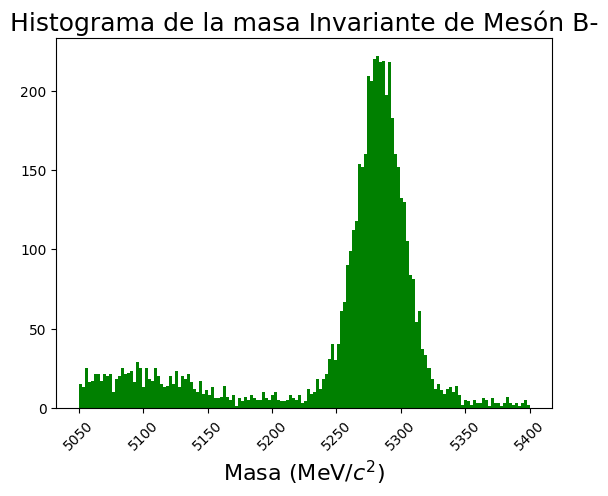

In [39]:
# make a variable for the charge of the B mesons
real_nB=real_data[(real_data['H1_Charge'] + real_data['H2_Charge'] + real_data['H3_Charge'] == -1)].copy()

#Calulo de la energía, momentum, y masa invariante de las tres partículas
real_nB = calcular_energia_momentum(real_nB, 'H1_PX', 'H1_PY', 'H1_PZ', 493.677, 'H1')
real_nB = calcular_energia_momentum(real_nB, 'H2_PX', 'H2_PY', 'H2_PZ', 493.677, 'H2')
real_nB = calcular_energia_momentum(real_nB, 'H3_PX', 'H3_PY', 'H3_PZ', 493.677, 'H3')

#Calculo de la energía y componentes del momentum de la partícula B-
real_nB['B_E']=real_nB['H1_E']+real_nB['H2_E']+real_nB['H3_E']
real_nB['B_PX']=real_nB['H1_PX']+real_nB['H2_PX']+real_nB['H3_PX']       #es necesario calcular cada componente
real_nB['B_PY']=real_nB['H1_PY']+real_nB['H2_PY']+real_nB['H3_PY']       #el momento es un vector
real_nB['B_PZ']=real_nB['H1_PZ']+real_nB['H2_PZ']+real_nB['H3_PZ']

# and the magnitude of the momentum of the B- meson
real_nB['B_P']=np.sqrt(real_nB['B_PX']**2+real_nB['B_PY']**2+real_nB['B_PZ']**2)
real_nB['B_M']=np.sqrt(real_nB['B_E']**2-real_nB['B_P']**2)

# plot the B meson invariant mass in a histogram
plt.hist(real_nB['B_M'],bins=150,range=(5050,5400), color = "green")
plt.xlabel(r"Masa (MeV/$c^2$)", fontsize = 16)
plt.xticks(rotation=45)
plt.title("Histograma de la masa Invariante de Mesón B-",fontsize=18)
plt.show()


In [40]:
# make variables for the numbers of positive and negative B mesons
B_values = real_B.shape[0]
print(f"No. de eventos de B+: {B_values}")
nB_values = real_nB.shape[0]
print(f"No. de eventos de B-: {nB_values}")

No. de eventos de B+: 6361
No. de eventos de B-: 5912


In [41]:
# calculate the value of the asymmetry, by using the formula above, and then print it
asymmetry=(nB_values-B_values)/(B_values+nB_values)
print(f"{asymmetry:.5f} es el valor de la asimetría")

-0.03658 es el valor de la asimetría


In [42]:
# calculate the statistical significance of your result and print it
significance=np.sqrt((1-asymmetry**2)/(B_values+nB_values))
print(f"La incerteza estadística es: {significance:.5f}")

#Calculo del sigma
sigma=asymmetry/significance
print(f"La significancia es de: {sigma:.2f} sigma")

La incerteza estadística es: 0.00902
La significancia es de: -4.06 sigma


In [ ]:
##Dalitz plots teoricos

In [43]:
#Función que organiza a las partículas por sus propiedades
def reorganizar_particulas(row):
    particulas = [
        {'charge': row['H1_Charge'], 'E': row['H1_E'], 'Px': row['H1_PX'], 'Py': row['H1_PY'], 'Pz': row['H1_PZ']},
        {'charge': row['H2_Charge'], 'E': row['H2_E'], 'Px': row['H2_PX'], 'Py': row['H2_PY'], 'Pz': row['H2_PZ']},
        {'charge': row['H3_Charge'], 'E': row['H3_E'], 'Px': row['H3_PX'], 'Py': row['H3_PY'], 'Pz': row['H3_PZ']}
    ]

    # Ordenar las partículas por su carga (primero positivos, luego negativos)
    particulas.sort(key=lambda x: x['charge'], reverse=True)

    # Actualizar el DataFrame con el nuevo orden
    for i, p in enumerate(particulas, start=1):
        row[f'H{i}_Charge'] = p['charge']
        row[f'H{i}_E'] = p['E']
        row[f'H{i}_PX'] = p['Px']
        row[f'H{i}_PY'] = p['Py']
        row[f'H{i}_PZ'] = p['Pz']

    return row

In [45]:
# calculate the invariant masses for each possible hadron pair combination

#Copia del data frame para B+
sim_df_B = sim_df[(sim_df['H1_Charge'] + sim_df['H2_Charge'] + sim_df['H3_Charge'] == 1)].copy()
#Se toman las columnas solo de interés
columnas_interes = ['H1_Charge','H1_E','H1_PX','H1_PY','H1_PZ','H2_Charge','H2_E','H2_PX','H2_PY','H2_PZ','H3_Charge','H3_E','H3_PX','H3_PY','H3_PZ']
new_df_B=sim_df[columnas_interes]

# Se reorganizar las partículas a través de la función
new_df_B = new_df_B.apply(reorganizar_particulas, axis=1)

#Calculo de la masa^2 invariante para R02 → K+1K-3
new_df_B['R+-'] = (
    (new_df_B['H1_E'] + new_df_B['H3_E'])**2 -
    ((new_df_B['H1_PX'] + new_df_B['H3_PX'])**2 +
     (new_df_B['H1_PY'] + new_df_B['H3_PY'])**2 +
     (new_df_B['H1_PZ'] + new_df_B['H3_PZ'])**2)
)

#Calculo de la masa^2 invariante para R03 → K+2K-3
new_df_B['R-+'] = (
    (new_df_B['H2_E'] + new_df_B['H3_E'])**2 -
    ((new_df_B['H2_PX'] + new_df_B['H3_PX'])**2 +
     (new_df_B['H2_PY'] + new_df_B['H3_PY'])**2 +
     (new_df_B['H2_PZ'] + new_df_B['H3_PZ'])**2)
)

#Calculo de la masa^2 invariante para R++1 → K+1K+2
new_df_B['R++'] = (
    (new_df_B['H2_E'] + new_df_B['H1_E'])**2 -
    ((new_df_B['H2_PX'] + new_df_B['H1_PX'])**2 +
     (new_df_B['H2_PY'] + new_df_B['H1_PY'])**2 +
     (new_df_B['H2_PZ'] + new_df_B['H1_PZ'])**2)
)

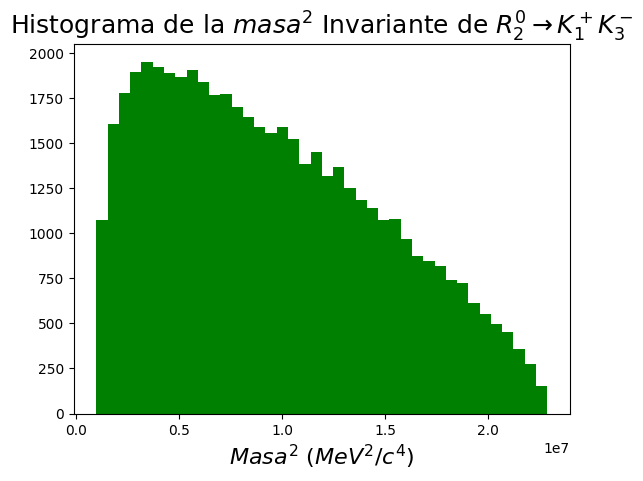

In [49]:
# plot the invariant mass for one of these combinations
plt.hist(new_df_B['R+-'], bins=40, color = "green")
plt.xlabel(r"$Masa^2$ ($MeV^2$/$c^4$)", fontsize = 16)
plt.title(r"Histograma de la $masa^2$ Invariante de $R^0_2 \to K^+_1K^-_3$",fontsize=18)
plt.show()

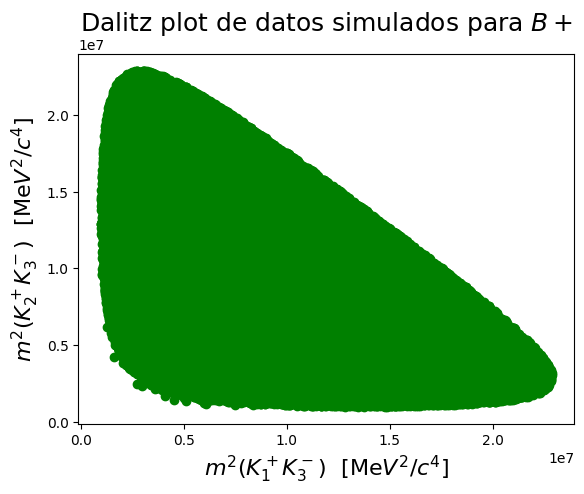

In [50]:
# make a Dalitz plot with labelled axes for the simulation data
plt.scatter(new_df_B['R+-'], new_df_B['R-+'], color = "green")
plt.xlabel(r"$m^2(K^+_1K^-_3)$  [Me$V^2$/$c^4$]", fontsize = 16)
plt.ylabel(r"$m^2(K^+_2K^-_3)$  [Me$V^2$/$c^4$]", fontsize = 16)
plt.title(r"Dalitz plot de datos simulados para $B+$",fontsize=18)
plt.show()


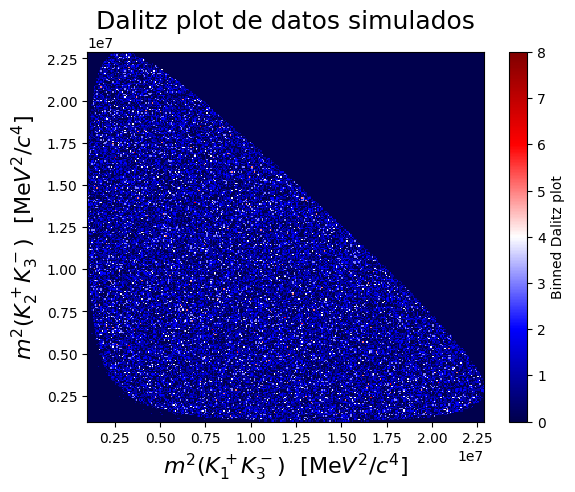

In [51]:
#Dalitz plot en un histograma en 2D
plt.hist2d(new_df_B['R+-'], new_df_B['R-+'], bins=300, cmap='seismic')
plt.colorbar(label='Binned Dalitz plot')
plt.xlabel(r"$m^2(K^+_1K^-_3)$  [Me$V^2$/$c^4$]", fontsize = 16)
plt.ylabel(r"$m^2(K^+_2K^-_3)$  [Me$V^2$/$c^4$]", fontsize = 16)
plt.title(r"Dalitz plot de datos simulados",fontsize=18)
plt.show()

In [ ]:
###DALITS PLOTS REAL DATA

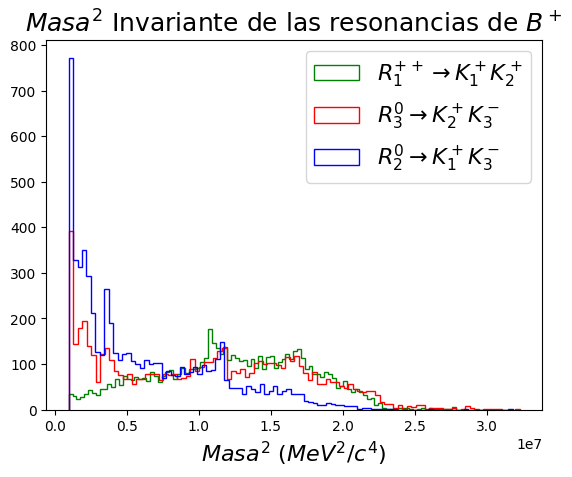

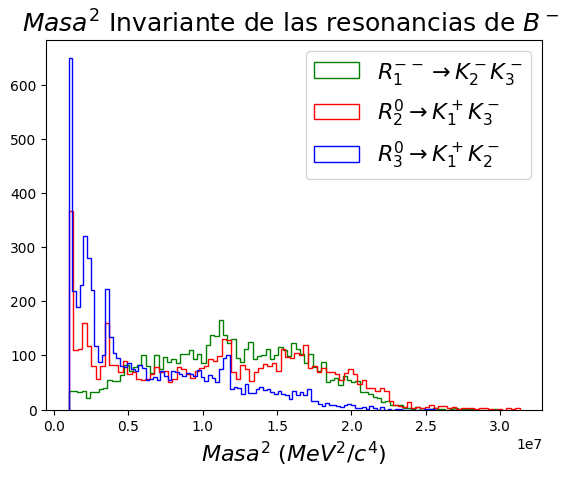

In [52]:
# calculate the invariant masses for each possible hadron pair combination in the real data

#Se reorganizan las partículas através de la función para B+
real_B = real_B.apply(reorganizar_particulas, axis=1)

#Calculo de la masa^2 invariante para R02 → K+1K-3
real_B['R+-'] = (
    (real_B['H1_E'] + real_B['H3_E'])**2 -
    ((real_B['H1_PX'] + real_B['H3_PX'])**2 +
     (real_B['H1_PY'] + real_B['H3_PY'])**2 +
     (real_B['H1_PZ'] + real_B['H3_PZ'])**2)
    )

#Calculo de la masa^2 invariante para R03 → K+2K-3
real_B['R-+'] = (
    (real_B['H2_E'] + real_B['H3_E'])**2 -
    ((real_B['H2_PX'] + real_B['H3_PX'])**2 +
     (real_B['H2_PY'] + real_B['H3_PY'])**2 +
     (real_B['H2_PZ'] + real_B['H3_PZ'])**2)
    )

#Calculo de la masa^2 invariante para R++1 → K+1K+2
real_B['R++'] = (
    (real_B['H1_E'] + real_B['H2_E'])**2 -
    ((real_B['H1_PX'] + real_B['H2_PX'])**2 +
     (real_B['H1_PY'] + real_B['H2_PY'])**2 +
     (real_B['H1_PZ'] + real_B['H2_PZ'])**2)
)

#Reorganización de las partículas através de la función
real_nB = real_nB.apply(reorganizar_particulas, axis=1)

#Calculo de la masa^2 invariante para R03 → K+1K-2
real_nB['nR+-'] = (
    (real_nB['H1_E'] + real_nB['H2_E'])**2 -
    ((real_nB['H1_PX'] + real_nB['H2_PX'])**2 +
     (real_nB['H1_PY'] + real_nB['H2_PY'])**2 +
     (real_nB['H1_PZ'] + real_nB['H2_PZ'])**2)
)

#Calculo de la masa^2 invariante para R02 → K+1K-3
real_nB['nR-+'] = (
    (real_nB['H1_E'] + real_nB['H3_E'])**2 -
    ((real_nB['H1_PX'] + real_nB['H3_PX'])**2 +
     (real_nB['H1_PY'] + real_nB['H3_PY'])**2 +
     (real_nB['H1_PZ'] + real_nB['H3_PZ'])**2)
)

#Calculo de la masa^2 invariante para R--1 → K-2K-3
real_nB['nR--'] = (
    (real_nB['H3_E'] + real_nB['H2_E'])**2 -
    ((real_nB['H3_PX'] + real_nB['H2_PX'])**2 +
     (real_nB['H3_PY'] + real_nB['H2_PY'])**2 +
     (real_nB['H3_PZ'] + real_nB['H2_PZ'])**2)
)

#Realizamos un histograma para la masa invariante

#Para B+
plt.hist(real_B['R++'], bins=100, color ="green", histtype='step', label = r"$R^{++}_1 \to K^+_1K^+_2$")
plt.hist(real_B['R-+'], bins=100, color ="red", histtype='step', label = r"$R^{0}_3 \to K^+_2K^-_3$")
plt.hist(real_B['R+-'], bins=100, color ="blue", histtype='step', label = r"$R^{0}_2 \to K^+_1K^-_3$")
plt.xlabel(r"$Masa^2$ ($MeV^2$/$c^4$)", fontsize = 16)
plt.title(r"$Masa^2$ Invariante de las resonancias de $B^+$",fontsize=18)
plt.legend(fontsize = 16)
plt.show()

#Para B-
plt.hist(real_nB['nR--'], bins=100, color ="green", histtype='step', label = r"$R^{--}_1 \to K^-_2K^-_3$")
plt.hist(real_nB['nR-+'], bins=100, color ="red", histtype='step', label = r"$R^{0}_2 \to K^+_1K^-_3$")
plt.hist(real_nB['nR+-'], bins=100, color ="blue", histtype='step', label = r"$R^{0}_3 \to K^+_1K^-_2$")
plt.xlabel(r"$Masa^2$ ($MeV^2$/$c^4$)", fontsize = 16)
plt.title(r"$Masa^2$ Invariante de las resonancias de $B^-$ ",fontsize=18)
plt.legend(fontsize = 16)
plt.show()

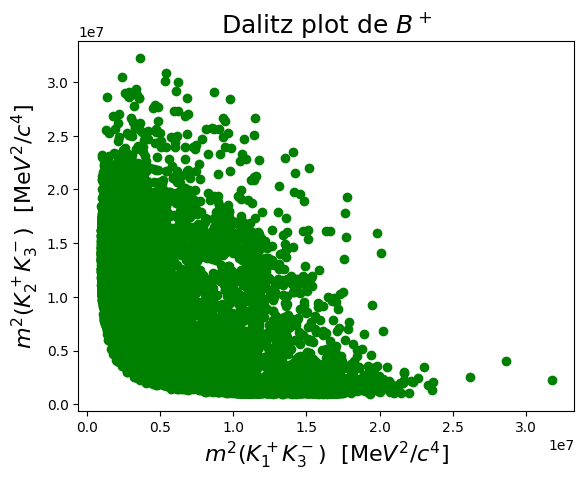

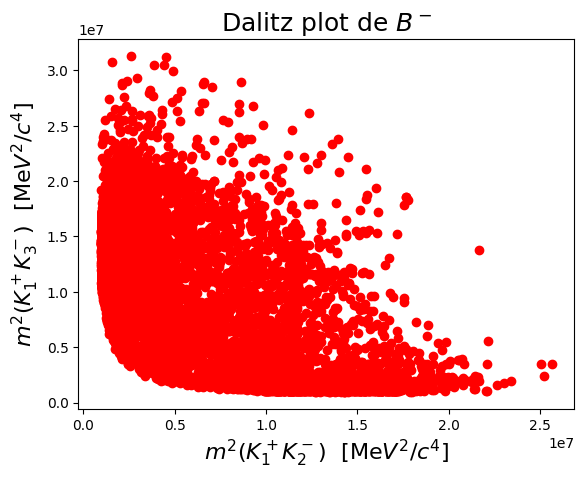

In [53]:
# make a Dalitz plot for the real data (with your preselection cuts applied)

#Dalitz plot para B+
plt.scatter(real_B['R+-'], real_B['R-+'], color="green")
plt.xlabel(r"$m^2(K^+_1K^-_3)$  [Me$V^2$/$c^4$]", fontsize = 16)
plt.ylabel(r"$m^2(K^+_2K^-_3)$  [Me$V^2$/$c^4$]", fontsize = 16)
plt.title(r"Dalitz plot de $B^+$",fontsize=18)
plt.show()

#Daltiz plot para B-
plt.scatter(real_nB['nR+-'], real_nB['nR-+'], color="red")
plt.xlabel(r"$m^2(K^+_1K^-_2)$  [Me$V^2$/$c^4$]", fontsize = 16)
plt.ylabel(r"$m^2(K^+_1K^-_3)$  [Me$V^2$/$c^4$]", fontsize = 16)
plt.title(r"Dalitz plot de $B^-$",fontsize=18)
plt.show()

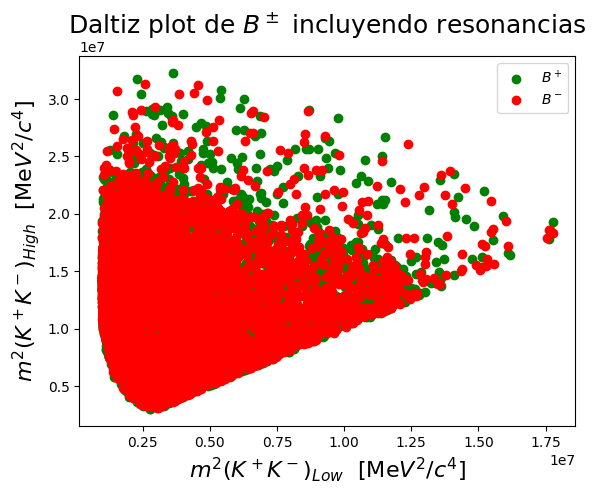

In [54]:
# make a new Dalitz plot with a mass ordering of the axes

#Determinamos los valores min y max de las resonancias de B+
real_B['R0Low'] = real_B[['R+-', 'R-+']].min(axis=1)
real_B['R0High'] = real_B[['R+-', 'R-+']].max(axis=1)

#Determinamos los valores min y max de las resonancias de B-
real_nB['R0Low'] = real_nB[['nR+-', 'nR-+']].min(axis=1)
real_nB['R0High'] = real_nB[['nR+-', 'nR-+']].max(axis=1)



#filtros para quitar resonancias

#Para B+
#Rango de R_Low
aux_filter_real_B = real_B[
    (real_B['R0Low'] < 1000**2) | (real_B['R0Low'] > 1050**2) &
    (real_B['R0Low'] < 1840**2) | (real_B['R0Low'] > 1890**2) &
    (real_B['R0Low'] < 3073**2) | (real_B['R0Low'] > 3123**2) &
    (real_B['R0Low'] < 3390**2) | (real_B['R0Low'] > 3440**2)].copy()

#Rango de R_high
filter_real_B = aux_filter_real_B[
    (aux_filter_real_B['R0High'] < 3400**2) | (aux_filter_real_B['R0High'] > 3450**2)].copy()

#Para B-
#Rango de R_low (franjas verticales)
aux_filter_real_nB = real_nB[
    (real_nB['R0Low'] < 1000**2) | (real_nB['R0Low'] > 1050**2) &
    (1840**2 > real_nB['R0Low']) | (real_nB['R0Low'] > 1890**2) &  #D0
    (real_nB['R0Low'] < 3073**2) | (real_nB['R0Low'] > 3123**2) &
    (real_nB['R0Low'] < 3390**2) | (real_nB['R0Low'] > 3440**2)].copy()  #Chi

#Rango de R_high
filter_real_nB = aux_filter_real_nB[
    (aux_filter_real_nB['R0High'] < 3400**2) | (aux_filter_real_nB['R0High'] > 3450**2)].copy() #Chi


#Dalitz plot de resonancias de B+/-
plt.scatter(real_B['R0Low'],real_B['R0High'],color="green", label = r"$B^+$")
plt.scatter(real_nB['R0Low'],real_nB['R0High'],color="red", label = r"$B^-$")
plt.xlabel(r"$m^2(K^+K^-)_{Low}$  [Me$V^2$/$c^4$]", fontsize = 16)
plt.ylabel(r"$m^2(K^+K^-)_{High}$  [Me$V^2$/$c^4$]", fontsize = 16)
plt.title(r"Daltiz plot de $B^\pm$ incluyendo resonancias",fontsize=18)
plt.legend(fontsize = 10)
plt.show()


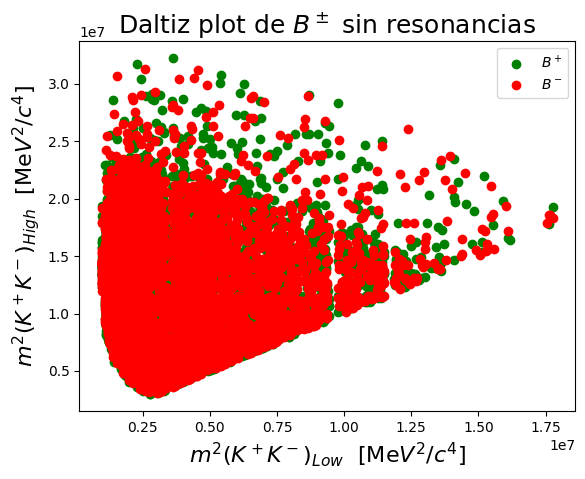

In [55]:
#Dalitz plot quitando las resonancias
plt.scatter(filter_real_B['R0Low'], filter_real_B['R0High'],color="green", label = r"$B^+$")
plt.scatter(filter_real_nB['R0Low'], filter_real_nB['R0High'],color="red", label = r"$B^-$")
plt.xlabel(r"$m^2(K^+K^-)_{Low}$  [Me$V^2$/$c^4$]", fontsize = 16)
plt.ylabel(r"$m^2(K^+K^-)_{High}$  [Me$V^2$/$c^4$]", fontsize = 16)
plt.title(r"Daltiz plot de $B^\pm$ sin resonancias",fontsize=18)
plt.legend(fontsize = 10)
plt.show()

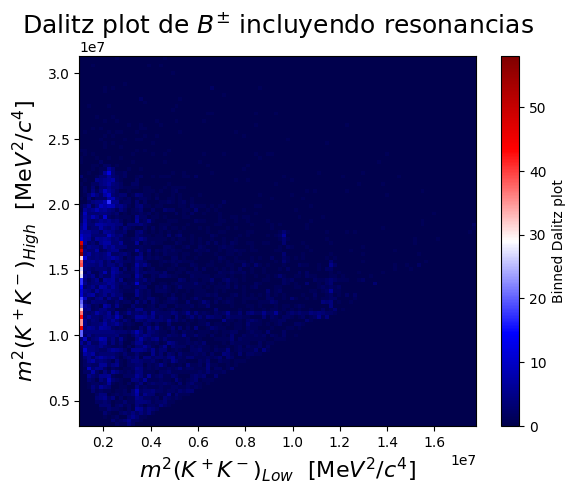

In [56]:
# plot a binned Dalitz Plot
# use colorbar() to make a legend for your plot at the side

#Para B+/-
plt.hist2d(real_B['R0Low'], real_B['R0High'], bins=100, cmap='seismic')
plt.hist2d(real_nB['R0Low'], real_nB['R0High'], bins=100, cmap='seismic')
plt.colorbar(label='Binned Dalitz plot')
plt.xlabel(r"$m^2(K^+K^-)_{Low}$  [Me$V^2$/$c^4$]", fontsize = 16)
plt.ylabel(r"$m^2(K^+K^-)_{High}$  [Me$V^2$/$c^4$]", fontsize = 16)
plt.title(r"Dalitz plot de $B^{\pm}$ incluyendo resonancias",fontsize=18)
plt.show()

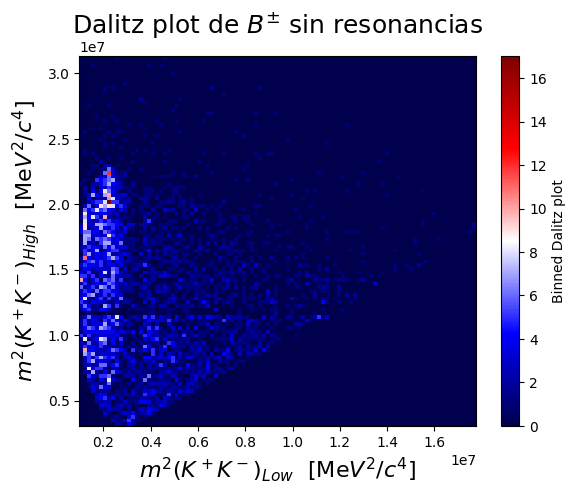

In [57]:
# plot a binned Dalitz Plot with no resonances

#Para B+/- sin resonancia
plt.hist2d(filter_real_B['R0Low'], filter_real_B['R0High'], bins=100, cmap='seismic')
plt.hist2d(filter_real_nB['R0Low'], filter_real_nB['R0High'], bins=100, cmap='seismic')
plt.colorbar(label='Binned Dalitz plot')
plt.xlabel(r"$m^2(K^+K^-)_{Low}$  [Me$V^2$/$c^4$]", fontsize = 16)
plt.ylabel(r"$m^2(K^+K^-)_{High}$  [Me$V^2$/$c^4$]", fontsize = 16)
plt.title(r"Dalitz plot de $B^{\pm}$ sin resonancias",fontsize=18)
plt.show()

No. de eventos de B+= 4982
No. de eventos de B-= 4537

El valor de la asimetría es = -0.04675
Incertidumbre estadística = 0.01024
El valor del sigma es = -4.56604


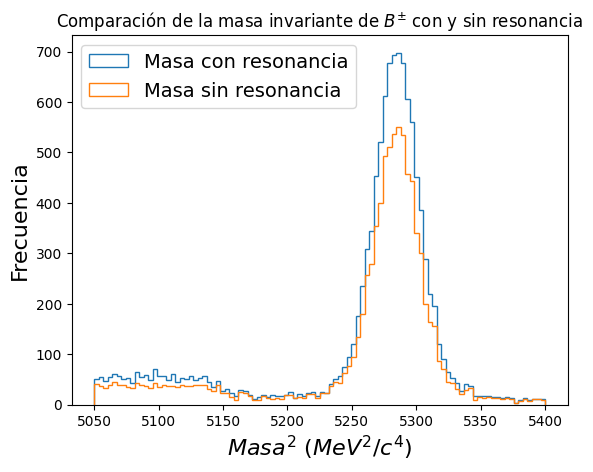

In [58]:
#Asimetria sin resonancias

#Determinamos la cantidad de eventos resultantes sin resonancia que genera B+
filter_B_values = filter_real_B.shape[0]
print('No. de eventos de B+=',filter_B_values)

#Determinamos la cantidad de eventos resultantes sin resonancia que genera B-
filter_nB_values = filter_real_nB.shape[0]
print('No. de eventos de B-=',filter_nB_values)

#Calculamos la asimetría
filter_asymmetry=(filter_nB_values-filter_B_values)/(filter_B_values+filter_nB_values)
print(f"\nEl valor de la asimetría es = {filter_asymmetry:.5f}")

#Calculo de la incertidumbre estadística
filter_significance=np.sqrt((1-filter_asymmetry**2)/(filter_B_values+filter_nB_values))
print(f"Incertidumbre estadística = {filter_significance:.5f}")

#Calculo del sigma
filter_sigma=filter_asymmetry/filter_significance
print(f"El valor del sigma es = {filter_sigma:.5f}")


#Almacenamiento de los datos una vez ya aplicado el filtro
nueva_columna = pandas.concat([filter_real_B['B_M'], filter_real_nB['B_M']], ignore_index=True)

# Agregarla al DataFrame como una nueva columna
df_combinado = pandas.DataFrame({'M_B+-': nueva_columna})

#Realización del histograma
plt.hist(real_df['B_M'], bins=100,range=(5050,5400), histtype='step',label = r"Masa con resonancia")
plt.hist(df_combinado['M_B+-'], bins=100,range=(5050,5400), histtype='step',label=r"Masa sin resonancia")
plt.title(r'Comparación de la masa invariante de $B^{\pm}$ con y sin resonancia')
plt.xlabel(r"$Masa^2$ ($MeV^2$/$c^4$)", fontsize = 16)
plt.ylabel('Frecuencia', fontsize = 16)
plt.legend(fontsize = 14)
plt.show()

In [ ]:
##COMPARANDO DALITZ PLOTS

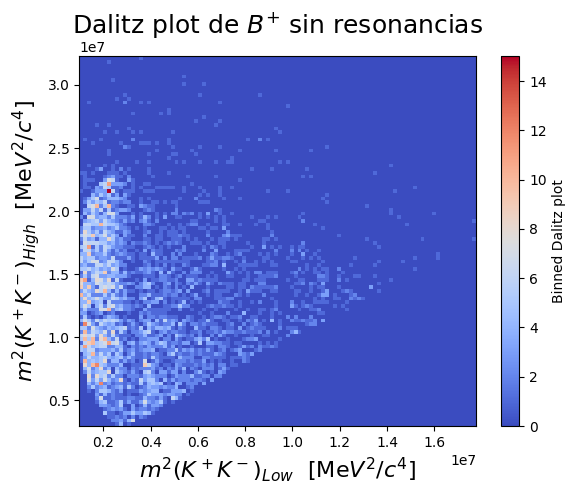

In [59]:
# make a Dalitz plot for the B+ events
plt.hist2d(filter_real_B['R0Low'], filter_real_B['R0High'], bins=100, cmap='coolwarm')
h1, xedges, yedges = np.histogram2d(filter_real_B['R0Low'], filter_real_B['R0High'], bins=10)
plt.colorbar(label='Binned Dalitz plot')
plt.xlabel(r"$m^2(K^+K^-)_{Low}$  [Me$V^2$/$c^4$]", fontsize = 16)
plt.ylabel(r"$m^2(K^+K^-)_{High}$  [Me$V^2$/$c^4$]", fontsize = 16)
plt.title(r"Dalitz plot de $B^{+}$ sin resonancias",fontsize=18)
plt.show()

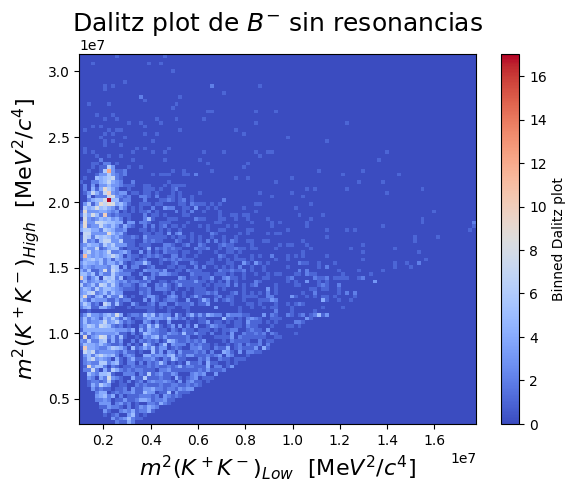

In [60]:
# make a Dalitz plot for the B- events
plt.hist2d(filter_real_nB['R0Low'], filter_real_nB['R0High'], bins=100, cmap='coolwarm')
h2, _, _ = np.histogram2d(filter_real_nB['R0Low'], filter_real_nB['R0High'], bins=10)
plt.colorbar(label='Binned Dalitz plot')
plt.xlabel(r"$m^2(K^+K^-)_{Low}$  [Me$V^2$/$c^4$]", fontsize = 16)
plt.ylabel(r"$m^2(K^+K^-)_{High}$  [Me$V^2$/$c^4$]", fontsize = 16)
plt.title(r"Dalitz plot de $B^{-}$ sin resonancias",fontsize=18)
plt.show()


/tmp/ipykernel_20716/569815546.py:5: RuntimeWarning: invalid value encountered in divide
  asymmetry = (h2 - h1) / (h2 + h1)


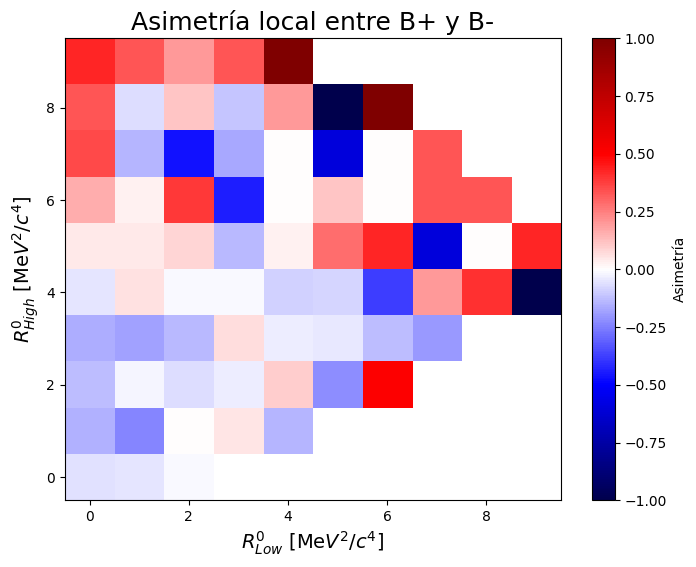

In [61]:
# Make a plot showing the asymmetry between these two Daltz plots
# i.e. calculate the asymmetry between each bin of the B+ and B- Dalitz plots and show the result in another 2D plot

#Calculo de la asimetría entre B+ y B-
asymmetry = (h2 - h1) / (h2 + h1)

# Crear el gráfico 2D de la asimetría
plt.figure(figsize=(8, 6))
plt.imshow(asymmetry.T, origin='lower', cmap='seismic', aspect='auto')
plt.colorbar(label='Asimetría')
plt.title('Asimetría local entre B+ y B-', fontsize = 18)
plt.xlabel(r'$R^0_{Low}$ [Me$V^2$/$c^4$]', fontsize = 14)
plt.ylabel(r'$R^0_{High}$ [Me$V^2$/$c^4$]', fontsize = 14)
plt.show()

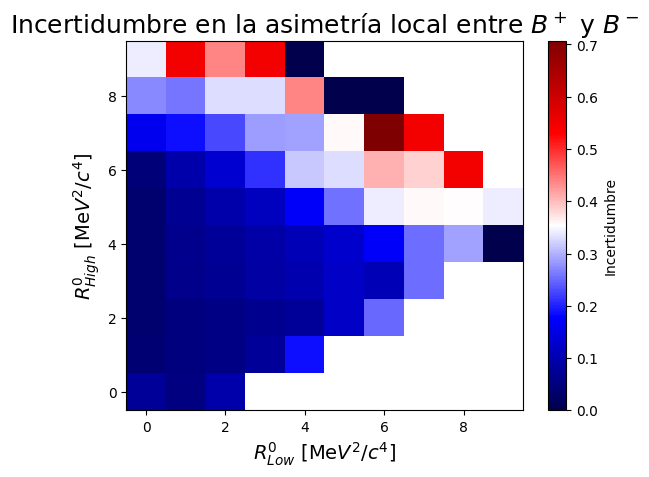

In [62]:
# Make a plot showing the uncertainty on the asymmetry

#Calculo de la incertidumbre
incertidumbre = np.sqrt((1 - asymmetry**2) / (h1 + h2))

#Grafica de la significancia
plt.imshow(incertidumbre.T, origin='lower', cmap='seismic', aspect='auto')

plt.colorbar(label='Incertidumbre')
plt.title(r'Incertidumbre en la asimetría local entre $B^+$ y $B^-$', fontsize = 18)
plt.xlabel(r'$R^0_{Low}$ [Me$V^2$/$c^4$]', fontsize = 14)
plt.ylabel(r'$R^0_{High}$ [Me$V^2$/$c^4$]', fontsize = 14)
plt.show()

/tmp/ipykernel_20716/1480428827.py:4: RuntimeWarning: divide by zero encountered in divide
  significancia=asymmetry/incertidumbre


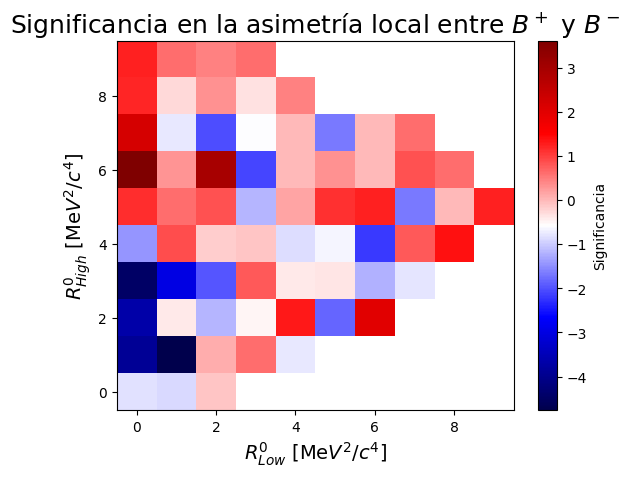

In [63]:
# Make a plot showing the statistical significance of the asymmetry

#Calculo de la significancia
significancia=asymmetry/incertidumbre

#Gráfica de la significancia
plt.imshow(significancia.T, origin='lower', cmap='seismic', aspect='auto')
plt.colorbar(label='Significancia')
plt.title(r'Significancia en la asimetría local entre $B^+$ y $B^-$', fontsize = 18)
plt.xlabel(r'$R^0_{Low}$ [Me$V^2$/$c^4$]', fontsize = 14)
plt.ylabel(r'$R^0_{High}$ [Me$V^2$/$c^4$]', fontsize = 14)
plt.show()

In [ ]:
###OBSERVAMOS VIOLACION CP

/tmp/ipykernel_20716/720502934.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  aux_filter2_real_B = filter_real_B[
/tmp/ipykernel_20716/720502934.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filter2_real_B = aux_filter2_real_B[


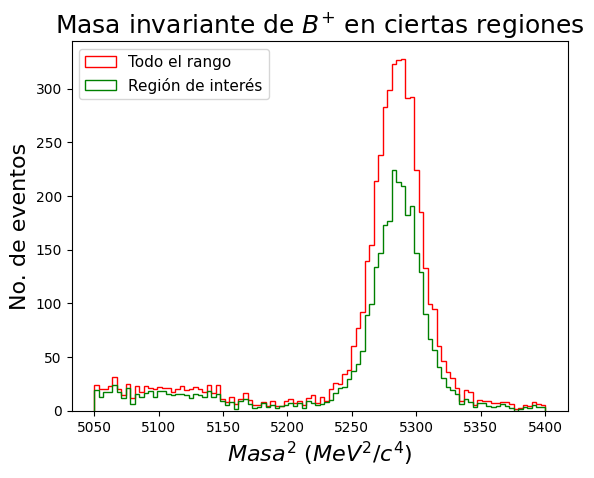

In [64]:
#Para B+
#Rango de R_Low
aux_filter_real_B = real_B[
    (real_B['R0Low'] < 1800**2) | (real_B['R0Low'] > 1900**2) &
    (real_B['R0Low'] < 3400**2) | (real_B['R0Low'] > 3450**2)].copy()

#Rango de R_high
filter_real_B = aux_filter_real_B[
    (aux_filter_real_B['R0High'] < 3400**2) | (aux_filter_real_B['R0High'] > 3450**2)].copy()



# Make a plot showing the invariant mass of the B+ meson particles

aux_filter2_real_B = filter_real_B[
    (aux_filter_real_B['R0High'] < 3800**2) | (aux_filter_real_B['R0High'] > 2000**2)].copy()

filter2_real_B = aux_filter2_real_B[
    (aux_filter_real_B['R0Low'] < 1800**2)].copy()

#Histograma de las masas invariantes para ciertas regiones
plt.hist(filter_real_B['B_M'], bins=100,range=(5050,5400), histtype='step',label=r"Todo el rango", color = "red")
plt.hist(filter2_real_B['B_M'], bins=100,range=(5050,5400), histtype='step',label=r"Región de interés", color = "green")
plt.title(r'Masa invariante de $B^{+}$ en ciertas regiones', fontsize = 18)
plt.xlabel(r"$Masa^2$ ($MeV^2$/$c^4$)", fontsize = 16)
plt.ylabel('No. de eventos', fontsize = 16)
plt.legend(fontsize = 11)
plt.show()

/tmp/ipykernel_20716/2047624259.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  aux_filter2_real_nB = filter_real_nB[
/tmp/ipykernel_20716/2047624259.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filter2_real_nB = aux_filter2_real_nB[


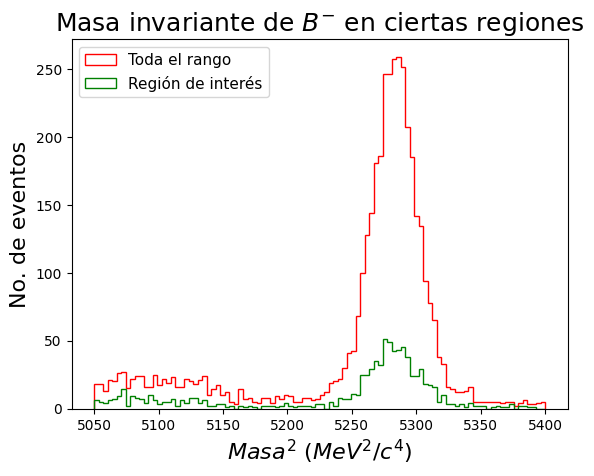

In [65]:
# Make a  showing the invariant mass of the B- meson particles using events from the same region

#Aplicando el filtro para solo ciertas regiones
aux_filter2_real_nB = filter_real_nB[
    (aux_filter_real_nB['R0High'] < 3400**2) | (aux_filter_real_B['R0High'] > 2000**2)].copy()

filter2_real_nB = aux_filter2_real_nB[
    (aux_filter_real_nB['R0Low'] < 1800**2)].copy()

#Histograma de masa invariante para ciertas regiones
plt.hist(filter_real_nB['B_M'], bins=100,range=(5050,5400), histtype='step',label=r"Toda el rango", color = "red")
plt.hist(filter2_real_nB['B_M'], bins=100,range=(5050,5400), histtype='step',label=r"Región de interés", color = "green")
plt.title(r'Masa invariante de $B^{-}$ en ciertas regiones', fontsize = 18)
plt.xlabel(r"$Masa^2$ ($MeV^2$/$c^4$)", fontsize = 16)
plt.ylabel('No. de eventos', fontsize = 16)
plt.legend(fontsize = 11)
plt.show()

In [66]:
#Asimetria local

#Cálculo de eventos de B+
filter2_B_values = filter2_real_B.shape[0]
print('No. de eventos de B+ = ',filter2_B_values)

#Calculo de eventos de B-
filter2_nB_values = filter2_real_nB.shape[0]
print('No. de eventos de B- =',filter2_nB_values)

#Cálculo de la asimetría
filter2_asymmetry=(filter2_nB_values-filter2_B_values)/(filter2_B_values+filter2_nB_values)
print('\nValor de la asimetría = ',filter2_asymmetry)

#Calculo de la incertidumbre estadística
filter2_significance=np.sqrt((1-filter2_asymmetry**2)/(filter2_B_values+filter2_nB_values))
print('Valor de la incertidumbre',filter2_significance)

#Cálculo de la significancia
filter2_sigma=filter2_asymmetry/filter2_significance
print('Un sigma = ',filter2_sigma)

No. de eventos de B+ =  3560
No. de eventos de B- = 888

Valor de la asimetría =  -0.6007194244604317
Valor de la incertidumbre 0.011987105004669367
Un sigma =  -50.1138034768555


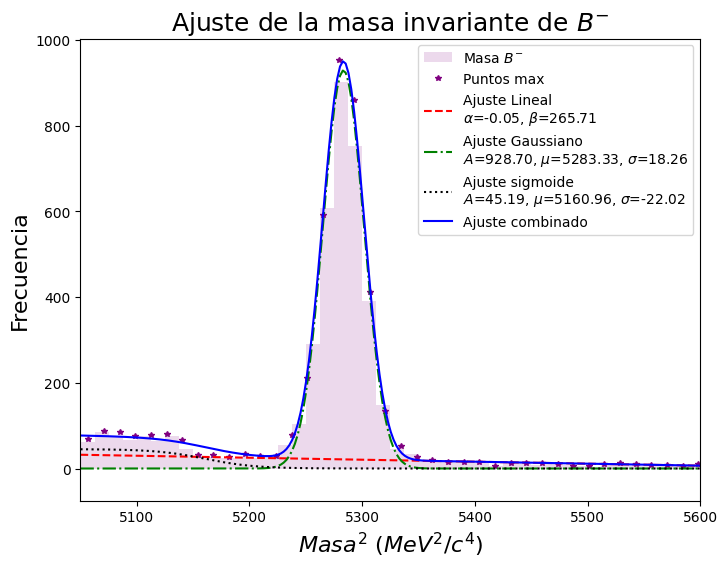

In [67]:
# Plot and fit the invariant mass of the B-meson

#Definición del ajuste lineal
def linear_fit(x, a, b):
    return a * x + b

#Definición del ajuste exponencial
def exp_decreasing_fit(x, A, k, C):
    return A * np.exp(-k * x) + C

#Definición del ajuste gaussiano
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

#Definición del ajuste sigmoidal
def sigmoid(x, A, mu2, gamma):
    return A / (1 + np.exp(-(x - mu2) / gamma))


#Extraemos la masa invariante sin resonancias en toda la región de B-
hist, bin_edges = np.histogram(filter_real_nB['B_M'], bins=90)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Graficar el histograma
plt.figure(figsize=(8, 6))
plt.hist(filter_real_nB['B_M'], bins=100, alpha=0.15, color='purple', label=r'Masa $B^{-}$')
plt.plot(bin_centers, hist, '*', label='Puntos max', color='purple', markersize=4)

#Ajuste lineal
filtered_data = filter_real_nB['B_M'][ (filter_real_nB['B_M'] > 5150)  & (filter_real_nB['B_M'] <= 5250) | ((filter_real_nB['B_M'] > 5300) & (filter_real_nB['B_M'] < 5800))].copy()
filtered_hist, filtered_bin_edges = np.histogram(filtered_data, bins=100)
filtered_bin_centers = (filtered_bin_edges[:-1] + filtered_bin_edges[1:]) / 2
params, covariance = curve_fit(linear_fit, filtered_bin_centers, filtered_hist, p0=[0, 40])
x_fit = np.linspace(bin_edges[0], bin_edges[-1], 500)
y_fit_linear = linear_fit(x_fit, *params)
#grafica lineal
plt.plot(x_fit, linear_fit(x_fit, *params), label=f'Ajuste Lineal\n$\\alpha$={params[0]:.2f}, $\\beta$={params[1]:.2f}', color='red', linestyle='--')


#Ajuste gaussiano
filtered2_data = filter_real_nB['B_M'].copy()
filtered2_hist, filtered2_bin_edges = np.histogram(filtered2_data, bins=95)
filtered2_bin_centers = (filtered2_bin_edges[:-1] + filtered2_bin_edges[1:]) / 2
params2, covariance2 = curve_fit(gaussian, filtered2_bin_centers, filtered2_hist, p0=[100, 5300, 3])
A, mu, sigma = params2
x2_fit = np.linspace(filtered2_bin_edges[0], filtered2_bin_edges[-1], 500)
y_fit_gaussian = gaussian(x2_fit, *params2)
#grafica gaussiana
plt.plot(x2_fit, gaussian(x2_fit, *params2), label=f'Ajuste Gaussiano\n$A$={A:.2f}, $\mu$={mu:.2f}, $\sigma$={sigma:.2f}', color='green', linestyle='-.')


#Ajuste sigmoidal
filtered3_data = filter_real_nB['B_M'][(filter_real_nB['B_M'] < 5200) ].copy()
filtered3_hist, filtered3_bin_edges = np.histogram(filtered3_data, bins=20)
filtered3_bin_centers = (filtered3_bin_edges[:-1] + filtered3_bin_edges[1:]) / 2
params3, covariance2 = curve_fit(sigmoid, filtered3_bin_centers, filtered3_hist, p0=[5000, 5100, 5000])
A, mu2, gamma = params3
x3_fit = np.linspace(bin_edges[0], bin_edges[-1], 500)
y_fit_sigmoid = sigmoid(x3_fit, *params3)
#grafica sigmoide
plt.plot(x3_fit, sigmoid(x3_fit, *params3), label=f'Ajuste sigmoide\n$A$={A:.2f}, $\mu$={mu2:.2f}, $\sigma$={gamma:.2f}', color='black', linestyle=':')


#Contribución de los 3 fits
total_curve = y_fit_linear + y_fit_gaussian + y_fit_sigmoid
plt.plot(x_fit, total_curve, label="Ajuste combinado", color='blue')


#ejes
plt.xlim(5050, 5600)
plt.title(r'Ajuste de la masa invariante de $B^{-}$', fontsize = 18)
plt.xlabel(r"$Masa^2$ ($MeV^2$/$c^4$)", fontsize = 16)
plt.ylabel('Frecuencia', fontsize = 16)
plt.legend()
plt.show()


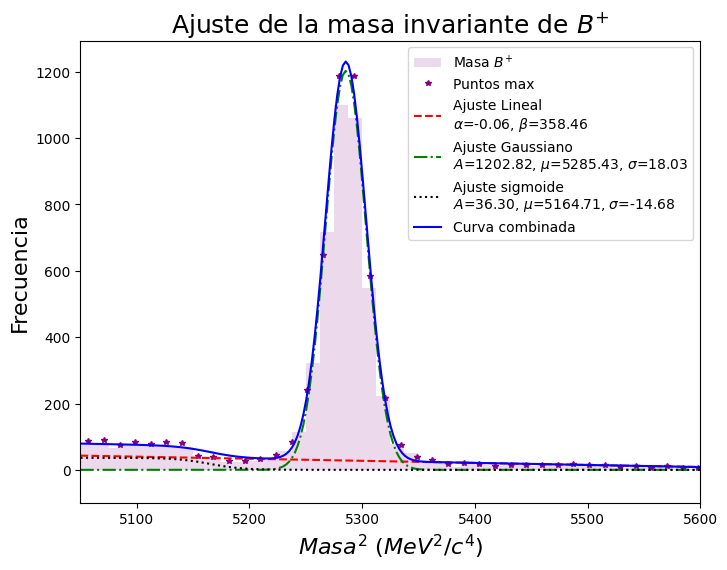

In [68]:
#Extraemos la masa invariante sin resonancias en toda la región de B+
plt.figure(figsize=(8, 6))
hist, bin_edges = np.histogram(filter_real_B['B_M'], bins=90)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Graficar el histograma
plt.hist(filter_real_B['B_M'], bins=100, alpha=0.15, color='purple', label=r'Masa $B^{+}$')
plt.plot(bin_centers, hist, '*', label='Puntos max', color='purple', markersize=4)

#Ajuste lineal
filtered_data = filter_real_B['B_M'][ (filter_real_B['B_M'] > 5150)  & (filter_real_B['B_M'] <= 5250) | ((filter_real_B['B_M'] > 5300) & (filter_real_B['B_M'] < 5800))].copy()
filtered_hist, filtered_bin_edges = np.histogram(filtered_data, bins=100)
filtered_bin_centers = (filtered_bin_edges[:-1] + filtered_bin_edges[1:]) / 2
params, covariance = curve_fit(linear_fit, filtered_bin_centers, filtered_hist, p0=[0, 40])
x_fit = np.linspace(bin_edges[0], bin_edges[-1], 500)
y_fit_linear = linear_fit(x_fit, *params)
#grafica lineal
plt.plot(x_fit, linear_fit(x_fit, *params), label=f'Ajuste Lineal\n$\\alpha$={params[0]:.2f}, $\\beta$={params[1]:.2f}', color='red', linestyle='--')


#Ajuste gaussino
filtered2_data = filter_real_B['B_M'].copy()
filtered2_hist, filtered2_bin_edges = np.histogram(filtered2_data, bins=95)
filtered2_bin_centers = (filtered2_bin_edges[:-1] + filtered2_bin_edges[1:]) / 2
params2B, covariance2B = curve_fit(gaussian, filtered2_bin_centers, filtered2_hist, p0=[100, 5300, 3])
A, mu, sigma = params2B
x2_fit = np.linspace(filtered2_bin_edges[0], filtered2_bin_edges[-1], 500)
y_fit_gaussian = gaussian(x2_fit, *params2B)
#grafica gaussiana
plt.plot(x2_fit, gaussian(x2_fit, *params2B), label=f'Ajuste Gaussiano\n$A$={A:.2f}, $\mu$={mu:.2f}, $\sigma$={sigma:.2f}', color='green', linestyle='-.')


#Ajuste sigmoidal
filtered3_data = filter_real_B['B_M'][(filter_real_B['B_M'] < 5170) ].copy()
filtered3_hist, filtered3_bin_edges = np.histogram(filtered3_data, bins=20)
filtered3_bin_centers = (filtered3_bin_edges[:-1] + filtered3_bin_edges[1:]) / 2
params3, covariance2 = curve_fit(sigmoid, filtered3_bin_centers, filtered3_hist, p0=[5000, 5000, 5000], maxfev=10000)
A, mu2, gamma = params3
x3_fit = np.linspace(bin_edges[0], bin_edges[-1], 500)
y_fit_sigmoid = sigmoid(x3_fit, *params3)
#grafica sigmoide
plt.plot(x3_fit, sigmoid(x3_fit, *params3), label=f'Ajuste sigmoide\n$A$={A:.2f}, $\mu$={mu2:.2f}, $\sigma$={gamma:.2f}', color='black', linestyle=':')


#Contribución de los 3 fits
total_curve = y_fit_linear + y_fit_gaussian + y_fit_sigmoid
plt.plot(x_fit, total_curve, label="Curva combinada", color='blue')


#ejes
plt.xlim(5050, 5600)
plt.title(r'Ajuste de la masa invariante de $B^{+}$', fontsize = 18)
plt.xlabel(r"$Masa^2$ ($MeV^2$/$c^4$)", fontsize = 16)
plt.ylabel('Frecuencia', fontsize = 16)
plt.legend()
plt.show()

In [69]:
# Calculate the CP asymmetry using the values extracted from the fit

#Area del histograma
area_minus = params2[0] * np.sqrt(2 * np.pi) * params2[2]
area_plus = params2B[0] * np.sqrt(2 * np.pi) * params2B[2]

#Cálculo de la asimetría
A_CP=(area_minus - area_plus) / (area_minus + area_plus)
# A_CP=(params2[0] - params2B[0]) / (params2[0] + params2B[0])

#Calculamos la incertidumbre apartir de los valores del fit
error_A_plus = np.sqrt(covariance2B[0, 0])
error_mu_plus = np.sqrt(covariance2B[1, 1])
error_sigma_plus = np.sqrt(covariance2B[2, 2])

error_A_minus = np.sqrt(covariance2[0, 0])
error_mu_minus = np.sqrt(covariance2[1, 1])
error_sigma_minus = np.sqrt(covariance2[2, 2])

delta = area_minus - area_plus
sigma = area_minus + area_plus
# delta = params2[0] - params2B[0]
# sigma = params2[0] + params2B[0]

error_area_minus = np.sqrt((np.sqrt(2 * np.pi) * params2[2] * error_A_minus)**2 +
                           (params2[0] * np.sqrt(2 * np.pi) * error_sigma_minus/params2[2])**2)

error_area_plus = np.sqrt((np.sqrt(2 * np.pi) * params2B[2] * error_A_plus)**2 +
                          (params2B[0] * np.sqrt(2 * np.pi) * error_sigma_plus /params2B[2] )**2)

#Incertidumbre estadística
sigma_A_CP = (2 / sigma**2) * np.sqrt((area_plus**2 * error_area_minus**2) +
                                      (area_minus**2 * error_area_plus**2))
# sigma_A_CP = (2 / sigma**2) * np.sqrt((params2B[0]**2 * error_area_minus**2) +
#                                       (params2[0]**2 * error_area_plus**2))

# Calcular significancia estadística
significance = abs(A_CP) / sigma_A_CP

#Impresión de los resultados
print(f"Asimetría de violación de CP (A_CP): {A_CP:.4f} ± {sigma_A_CP:.4f}")
print(f"Significancia estadística: {significance:.2f} sigma")
print(f"\nÁrea B-: {area_minus:.4f} ± {error_area_minus:.4f}")
print(f"Área B+: {area_plus:.4f} ± {error_area_plus:.4f}")

Asimetría de violación de CP (A_CP): -0.1222 ± 0.0145
Significancia estadística: 8.43 sigma

Área B-: 42514.3957 ± 991.4890
Área B+: 54353.4377 ± 975.3559


In [ ]:
###INCERTEZAS

/tmp/ipykernel_20716/3504260219.py:13: RuntimeWarning: overflow encountered in power
  power_law = (B - (x - mu) / sigma) ** (-n)
/tmp/ipykernel_20716/3504260219.py:13: RuntimeWarning: invalid value encountered in power
  power_law = (B - (x - mu) / sigma) ** (-n)
/tmp/ipykernel_20716/3504260219.py:42: OptimizeWarning: Covariance of the parameters could not be estimated
  params2, covariance2 = curve_fit(crystal_ball, filtered2_bin_centers, filtered2_hist, p0=[1.5, 5, 5300, 100, 100, 10], maxfev=10000)


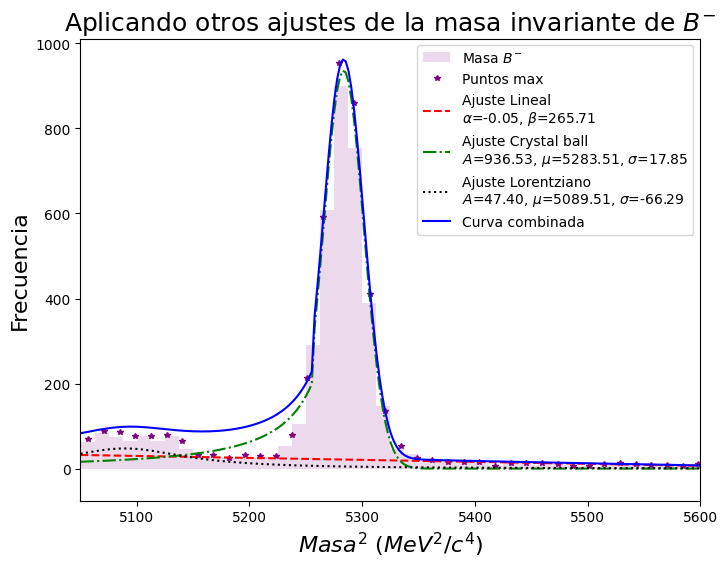

In [70]:
# Plot and fit the invariant mass of the B-meson using another fit function

#Ajuste de la función lorentziana
def lorentzian(x, A, mu, gamma):
    return A / (1 + ((x - mu) / gamma)**2)

#Ajuste de la función crystal ball
def crystal_ball(x, alpha, n, mu, sigma, A, B):
    # Parte Gaussiana
    gauss = np.exp(-0.5 * ((x - mu) / sigma) ** 2)

    # Parte de la cola
    power_law = (B - (x - mu) / sigma) ** (-n)

    # Aplicar la condición para elegir entre la Gaussiana y la cola
    return np.where((x - mu) / sigma > -alpha, A * gauss, A * power_law)

#Extraemos la masa invariante sin resonancias en toda la región de B-
hist, bin_edges = np.histogram(filter_real_nB['B_M'], bins=90)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Graficar el histograma
plt.figure(figsize=(8, 6))
plt.hist(filter_real_nB['B_M'], bins=100, alpha=0.15, color='purple', label=r'Masa $B^{-}$')
plt.plot(bin_centers, hist, '*', label='Puntos max', color='purple', markersize=4)

#Ajuste lineal
filtered_data = filter_real_nB['B_M'][ (filter_real_nB['B_M'] > 5150)  & (filter_real_nB['B_M'] <= 5250) | ((filter_real_nB['B_M'] > 5300) & (filter_real_nB['B_M'] < 5800))].copy()
filtered_hist, filtered_bin_edges = np.histogram(filtered_data, bins=100)
filtered_bin_centers = (filtered_bin_edges[:-1] + filtered_bin_edges[1:]) / 2
params, covariance = curve_fit(linear_fit, filtered_bin_centers, filtered_hist, p0=[0, 40])
x_fit = np.linspace(bin_edges[0], bin_edges[-1], 500)
y_fit_linear = linear_fit(x_fit, *params)
#grafica lineal
plt.plot(x_fit, linear_fit(x_fit, *params), label=f'Ajuste Lineal\n$\\alpha$={params[0]:.2f}, $\\beta$={params[1]:.2f}', color='red', linestyle='--')


#Ajuste por la función crystal_ball
filtered2_data = filter_real_nB['B_M'].copy()
filtered2_hist, filtered2_bin_edges = np.histogram(filtered2_data, bins=95)
filtered2_bin_centers = (filtered2_bin_edges[:-1] + filtered2_bin_edges[1:]) / 2
params2, covariance2 = curve_fit(crystal_ball, filtered2_bin_centers, filtered2_hist, p0=[1.5, 5, 5300, 100, 100, 10], maxfev=10000)
alpha, n, mu, sigma, A, B = params2
x2_fit = np.linspace(filtered2_bin_edges[0], filtered2_bin_edges[-1], 500)
y_fit_gaussian =crystal_ball(x2_fit, *params2)
#grafica crystal_ball
plt.plot(x2_fit, crystal_ball(x2_fit, *params2), label=f'Ajuste Crystal ball\n$A$={A:.2f}, $\mu$={mu:.2f}, $\sigma$={sigma:.2f}', color='green', linestyle='-.')


#Ajuste por la función lorentiana
filtered3_data = filter_real_nB['B_M'][(filter_real_nB['B_M'] < 5200) ].copy()
filtered3_hist, filtered3_bin_edges = np.histogram(filtered3_data, bins=20)
filtered3_bin_centers = (filtered3_bin_edges[:-1] + filtered3_bin_edges[1:]) / 2
params3, covariance2 = curve_fit(lorentzian, filtered3_bin_centers, filtered3_hist, p0=[5000, 5100, 5000])
A, mu2, gamma = params3
x3_fit = np.linspace(bin_edges[0], bin_edges[-1], 500)
y_fit_lorentzian = lorentzian(x3_fit, *params3)
#grafica lorentziana
plt.plot(x3_fit, lorentzian(x3_fit, *params3), label=f'Ajuste Lorentziano\n$A$={A:.2f}, $\mu$={mu2:.2f}, $\sigma$={gamma:.2f}', color='black', linestyle=':')


#Contribución de los 3 fits
total_curve = y_fit_linear + y_fit_gaussian + y_fit_lorentzian
plt.plot(x_fit, total_curve, label="Curva combinada", color='blue')

plt.xlim(5050, 5600)
plt.title(r'Aplicando otros ajustes de la masa invariante de $B^{-}$', fontsize = 18)
plt.xlabel(r"$Masa^2$ ($MeV^2$/$c^4$)", fontsize = 16)
plt.ylabel('Frecuencia', fontsize = 16)
plt.legend()
plt.show()

/tmp/ipykernel_20716/3504260219.py:13: RuntimeWarning: overflow encountered in power
  power_law = (B - (x - mu) / sigma) ** (-n)
/tmp/ipykernel_20716/3504260219.py:13: RuntimeWarning: invalid value encountered in power
  power_law = (B - (x - mu) / sigma) ** (-n)
/tmp/ipykernel_20716/3615227174.py:25: OptimizeWarning: Covariance of the parameters could not be estimated
  params2B, covariance2 = curve_fit(crystal_ball, filtered2_bin_centers, filtered2_hist, p0=[1.5, 5, 5300, 100, 100, 10], maxfev=10000)


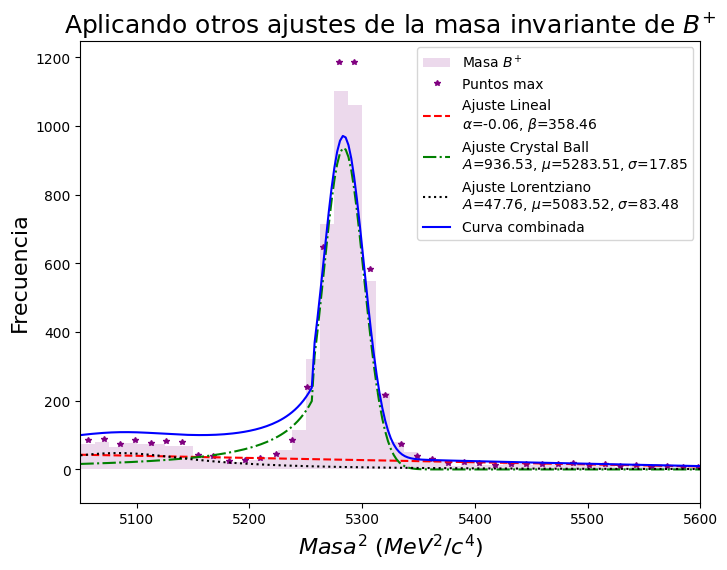

In [71]:
#Extraemos la masa invariante sin resonancias en toda la región de B+
hist, bin_edges = np.histogram(filter_real_B['B_M'], bins=90)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Graficar el histograma
plt.figure(figsize=(8, 6))
plt.hist(filter_real_B['B_M'], bins=100, alpha=0.15, color='purple', label=r'Masa $B^{+}$')
plt.plot(bin_centers, hist, '*', label='Puntos max', color='purple', markersize=4)

#Ajuste lineal
filtered_data = filter_real_B['B_M'][ (filter_real_B['B_M'] > 5150)  & (filter_real_B['B_M'] <= 5250) | ((filter_real_B['B_M'] > 5300) & (filter_real_B['B_M'] < 5800))].copy()
filtered_hist, filtered_bin_edges = np.histogram(filtered_data, bins=100)
filtered_bin_centers = (filtered_bin_edges[:-1] + filtered_bin_edges[1:]) / 2
params, covariance = curve_fit(linear_fit, filtered_bin_centers, filtered_hist, p0=[0, 40])
x_fit = np.linspace(bin_edges[0], bin_edges[-1], 500)
y_fit_linear = linear_fit(x_fit, *params)
#grafica lineal
plt.plot(x_fit, linear_fit(x_fit, *params), label=f'Ajuste Lineal\n$\\alpha$={params[0]:.2f}, $\\beta$={params[1]:.2f}', color='red', linestyle='--')


#Ajuste de la función crystal_ball
filtered2_data = filter_real_B['B_M'].copy()
filtered2_hist, filtered2_bin_edges = np.histogram(filtered2_data, bins=95)
filtered2_bin_centers = (filtered2_bin_edges[:-1] + filtered2_bin_edges[1:]) / 2
params2B, covariance2 = curve_fit(crystal_ball, filtered2_bin_centers, filtered2_hist, p0=[1.5, 5, 5300, 100, 100, 10], maxfev=10000)
alpha, n, mu, sigma, A, B = params2
x2_fit = np.linspace(filtered2_bin_edges[0], filtered2_bin_edges[-1], 500)
y_fit_gaussian =crystal_ball(x2_fit, *params2)
#grafica crystal_ball
plt.plot(x2_fit, crystal_ball(x2_fit, *params2), label=f'Ajuste Crystal Ball\n$A$={A:.2f}, $\mu$={mu:.2f}, $\sigma$={sigma:.2f}', color='green', linestyle='-.')


#Ajuste de la función lorentziana
filtered3_data = filter_real_B['B_M'][(filter_real_B['B_M'] < 5200) ].copy()
filtered3_hist, filtered3_bin_edges = np.histogram(filtered3_data, bins=20)
filtered3_bin_centers = (filtered3_bin_edges[:-1] + filtered3_bin_edges[1:]) / 2
params3, covariance2 = curve_fit(lorentzian, filtered3_bin_centers, filtered3_hist, p0=[5000, 5100, 5000])
A, mu2, gamma = params3
x3_fit = np.linspace(bin_edges[0], bin_edges[-1], 500)
y_fit_lorentzian = lorentzian(x3_fit, *params3)
#grafica lorentziana
plt.plot(x3_fit, lorentzian(x3_fit, *params3), label=f'Ajuste Lorentziano\n$A$={A:.2f}, $\mu$={mu2:.2f}, $\sigma$={gamma:.2f}', color='black', linestyle=':')


#Contribución de los 3 fits
total_curve = y_fit_linear + y_fit_gaussian + y_fit_lorentzian
plt.plot(x_fit, total_curve, label="Curva combinada", color='blue')

plt.xlim(5050, 5600)
plt.title(r'Aplicando otros ajustes de la masa invariante de $B^{+}$', fontsize = 18)
plt.xlabel(r"$Masa^2$ ($MeV^2$/$c^4$)", fontsize = 16)
plt.ylabel('Frecuencia', fontsize = 16)
plt.legend()
plt.show()

In [72]:
# Calculate the CP asymmetry using the values extracted from the fit
area_minus = params2[4] * np.sqrt(2 * np.pi) * params2[3]
area_plus = params2B[4] * np.sqrt(2 * np.pi) * params2B[3]

#Calculo de la asimetría
A_CP2=(area_minus - area_plus) / (area_minus + area_plus)
print(f"Asimetría de violación de CP (A_CP): {A_CP2}")

Asimetría de violación de CP (A_CP): -0.1223843028649438


In [73]:
# Compute the systematic uncertainty
systematic_uncertainty = A_CP2-A_CP
print(f"La incerteza sistemática = {systematic_uncertainty:.5f}")

La incerteza sistemática = -0.00017
